# YOLOv8 Backbone + Logistic Regression

Simple object-classification baseline for Santos: each YOLO label row becomes one object crop, a frozen YOLOv8 backbone turns the crop into an embedding, and logistic regression predicts `MILCO` vs `NOMBO`.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from ultralytics import YOLO

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data" / "santos").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data" / "santos"
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"
CLASS_NAMES = ["MILCO", "NOMBO"]

CHECKPOINT_PATH = REPO_ROOT / "yolov8n.pt"
BACKBONE_END_LAYER = 9
IMG_SIZE = 640
CROP_PAD = 1.0
TEST_FRAC = 0.15
VAL_FRAC = 0.15
RANDOM_SEED = 42
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"repo: {REPO_ROOT}")
print(f"checkpoint: {CHECKPOINT_PATH}")
print(f"device: {DEVICE}")

repo: /Users/adityakoushik/Desktop/sonar_mines
checkpoint: /Users/adityakoushik/Desktop/sonar_mines/yolov8n.pt
device: cpu


## Build Object Table

Each row is one ground-truth object: image path, class, and normalized YOLO box (`cx cy w h`).

In [3]:
image_exts = (".jpg", ".jpeg", ".png")


def read_yolo_labels(path: Path):
    for target_index, line in enumerate(path.read_text().splitlines()):
        if not line.strip():
            continue
        cls, cx, cy, w, h = line.split()[:5]
        yield target_index, int(cls), float(cx), float(cy), float(w), float(h)


records = []
for image_path in sorted(p for ext in image_exts for p in IMAGES_DIR.glob(f"*{ext}")):
    label_path = LABELS_DIR / f"{image_path.stem}.txt"
    if not label_path.exists():
        continue
    for target_index, cls, cx, cy, w, h in read_yolo_labels(label_path):
        records.append(
            {
                "image_path": image_path,
                "stem": image_path.stem,
                "target_index": target_index,
                "cls": cls,
                "cx": cx,
                "cy": cy,
                "w": w,
                "h": h,
            }
        )

df = pd.DataFrame(records)
if df.empty:
    raise ValueError(f"no labels found under {LABELS_DIR}")

display(df.head())
print(f"objects: {len(df)}")
display(df["cls"].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES))).to_frame("count"))

,image_path,stem,target_index,cls,cx,cy,w,h
0,/Users/adityakoushik/Desktop/sonar_mines/data/...,0001_2015,0,0,0.100098,0.226562,0.053711,0.029297
1,/Users/adityakoushik/Desktop/sonar_mines/data/...,0001_2015,1,1,0.430176,0.444336,0.038086,0.054688
2,/Users/adityakoushik/Desktop/sonar_mines/data/...,0001_2015,2,0,0.587891,0.708008,0.021484,0.019531
3,/Users/adityakoushik/Desktop/sonar_mines/data/...,0001_2015,3,0,0.842285,0.859375,0.030273,0.019531
4,/Users/adityakoushik/Desktop/sonar_mines/data/...,0001_2015,4,1,0.171387,0.878906,0.024414,0.017578


objects: 668


,count
cls,
MILCO,437
NOMBO,231


## Split

Random stratified 70/15/15 split over object rows.

In [4]:
y = df["cls"].to_numpy(dtype=int)
idx = np.arange(len(df))

trainval_idx, test_idx = train_test_split(
    idx,
    test_size=TEST_FRAC,
    random_state=RANDOM_SEED,
    stratify=y,
)
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=VAL_FRAC / (1 - TEST_FRAC),
    random_state=RANDOM_SEED,
    stratify=y[trainval_idx],
)

split_counts = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "n": [len(train_idx), len(val_idx), len(test_idx)],
    }
)
display(split_counts)

def class_counts(indices, name):
    return pd.crosstab(df.loc[indices, "cls"], columns=name)

display(
    pd.concat([class_counts(train_idx, "train"), class_counts(val_idx, "val"), class_counts(test_idx, "test")], axis=1)
    .rename(index=dict(enumerate(CLASS_NAMES)))
)

,split,n
0,train,466
1,val,101
2,test,101


col_0,train,val,test
cls,,,
MILCO,305,66,66
NOMBO,161,35,35


## Extract Embeddings

The crop uses the ground-truth box plus padding. YOLOv8 layers `0-9` are frozen and pooled to one vector per crop.

In [5]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"expected YOLOv8 checkpoint at {CHECKPOINT_PATH}")

yolo = YOLO(str(CHECKPOINT_PATH))
backbone = torch.nn.Sequential(*list(yolo.model.model[: BACKBONE_END_LAYER + 1])).to(DEVICE).eval()
for param in backbone.parameters():
    param.requires_grad_(False)


def crop_bounds(row, image_size):
    width, height = image_size
    box_w, box_h = row.w * width, row.h * height
    cx, cy = row.cx * width, row.cy * height
    x1, y1 = cx - box_w / 2, cy - box_h / 2
    x2, y2 = cx + box_w / 2, cy + box_h / 2

    x1 = int(np.floor(x1 - CROP_PAD * box_w))
    y1 = int(np.floor(y1 - CROP_PAD * box_h))
    x2 = int(np.ceil(x2 + CROP_PAD * box_w))
    y2 = int(np.ceil(y2 + CROP_PAD * box_h))

    x1 = min(max(x1, 0), width - 1)
    y1 = min(max(y1, 0), height - 1)
    x2 = min(max(x2, x1 + 1), width)
    y2 = min(max(y2, y1 + 1), height)
    return x1, y1, x2, y2


def load_crop(row):
    image = Image.open(row.image_path).convert("RGB")
    crop = image.crop(crop_bounds(row, image.size)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    arr = np.asarray(crop, dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1)


@torch.no_grad()
def embed(rows):
    vectors = []
    rows = list(rows)
    for start in range(0, len(rows), BATCH_SIZE):
        batch = rows[start : start + BATCH_SIZE]
        images = torch.stack([load_crop(row) for row in batch]).to(DEVICE)
        features = backbone(images)
        vectors.append(F.adaptive_avg_pool2d(features, 1).flatten(1).cpu().numpy())
    return np.concatenate(vectors)


X = embed(df.itertuples(index=False))
print(f"embeddings: {X.shape}")

embeddings: (668, 256)


## Train And Evaluate

In [6]:
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
)
clf.fit(X[train_idx], y[train_idx])

pred_val = clf.predict(X[val_idx])
pred_test = clf.predict(X[test_idx])

metrics = pd.Series(
    {
        "val_accuracy": accuracy_score(y[val_idx], pred_val),
        "val_balanced_accuracy": balanced_accuracy_score(y[val_idx], pred_val),
        "test_accuracy": accuracy_score(y[test_idx], pred_test),
        "test_balanced_accuracy": balanced_accuracy_score(y[test_idx], pred_test),
    }
)
display(metrics.to_frame("value"))

labels = list(range(len(CLASS_NAMES)))
print(classification_report(y[test_idx], pred_test, labels=labels, target_names=CLASS_NAMES, zero_division=0))
display(pd.DataFrame(confusion_matrix(y[test_idx], pred_test, labels=labels), index=CLASS_NAMES, columns=CLASS_NAMES))

,value
val_accuracy,0.722772
val_balanced_accuracy,0.707359
test_accuracy,0.702970
test_balanced_accuracy,0.698918


              precision    recall  f1-score   support

       MILCO       0.81      0.71      0.76        66
       NOMBO       0.56      0.69      0.62        35

    accuracy                           0.70       101
   macro avg       0.68      0.70      0.69       101
weighted avg       0.72      0.70      0.71       101



,MILCO,NOMBO
MILCO,47,19
NOMBO,11,24


## PCA View

Project the 256-dimensional crop embeddings to 2D and color by class.

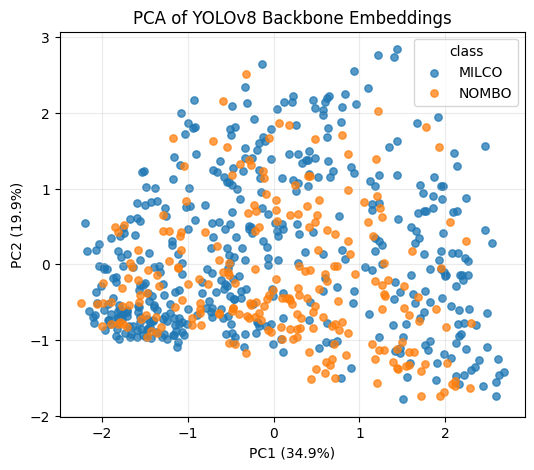

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(6, 5))
for class_id, class_name in enumerate(CLASS_NAMES):
    mask = y == class_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=28, alpha=0.75, label=class_name)

ax.set_title("PCA of YOLOv8 Backbone Embeddings")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(title="class")
ax.grid(alpha=0.25)
plt.show()

## 3D PCA View

Same embeddings as above, projected onto the first three principal components.

In [8]:
import plotly.express as px

pca3 = PCA(n_components=3, random_state=RANDOM_SEED)
X_pca3 = pca3.fit_transform(X)

pca3_df = pd.DataFrame(
    {
        "PC1": X_pca3[:, 0],
        "PC2": X_pca3[:, 1],
        "PC3": X_pca3[:, 2],
        "class": [CLASS_NAMES[class_id] for class_id in y],
    }
)

fig = px.scatter_3d(
    pca3_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="class",
    opacity=0.75,
    title="3D PCA of YOLOv8 Backbone Embeddings",
    labels={
        "PC1": f"PC1 ({pca3.explained_variance_ratio_[0]:.1%})",
        "PC2": f"PC2 ({pca3.explained_variance_ratio_[1]:.1%})",
        "PC3": f"PC3 ({pca3.explained_variance_ratio_[2]:.1%})",
    },
)
fig.update_traces(marker={"size": 4})
fig.update_layout(scene={"aspectmode": "cube"}, legend_title_text="class")
fig.show()

## UMAP View

Nonlinear 2D projection of the same 256-dimensional embeddings.

/Users/adityakoushik/Desktop/sonar_mines/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


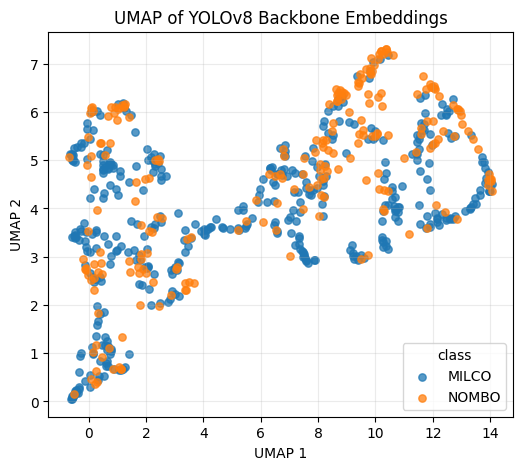

In [9]:
try:
    from umap import UMAP
except ImportError as exc:
    raise ImportError("Install umap-learn to run this cell: pip install umap-learn") from exc

umap_model = UMAP(n_components=2, random_state=RANDOM_SEED)
X_umap = umap_model.fit_transform(X)

fig, ax = plt.subplots(figsize=(6, 5))
for class_id, class_name in enumerate(CLASS_NAMES):
    mask = y == class_id
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1], s=28, alpha=0.75, label=class_name)

ax.set_title("UMAP of YOLOv8 Backbone Embeddings")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(title="class")
ax.grid(alpha=0.25)
plt.show()